# 250402 Trying again to make complex numbers work

~~This also failed, but it was worth a shot.~~ We got it working! We just needed to correctly handle the plots, since we are trying to look at the **phase shift** rather than the coefficients themselves. The good news is that we now know that our code can handle complex numbers just fine. 

We were trying to get complex numbers to work in our simulation and produce meaningful results with them. The $r_s$ and $r_p$ functions in the BYU book on p 82 incorporate this change in the way we find the $\cos \theta_t$ values. ~~and I hoped that would work but it doesn't seem to yet. Perhaps in the future?~~

One note here is that the equations 3.41 and 3.42 that we were trying to make work as well as the 3.40 may have been wrong in double counting the complex numbers? I need to try to figure this out but I switched the things under the radical in python as he did in 3.40, but numpy needs to know that complex numbers are allowed in order to use them. I did this by putting a 0j in the radical.~~, but that didn't work.~~ Yes it did!

In [1]:
%matplotlib widget

from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [4]:
def phasePlot(func1, func2, func3, func4):
    fig0 = plt.figure(figsize=(8,5))
    ax0 = fig0.add_subplot(111)
    thi = np.linspace(0.1,89.9,10000)
    line01, = ax0.plot([],[], 'r^')
    line02, = ax0.plot([],[], 'b^')
    line03, = ax0.plot([],[], 'r-')
    line04, = ax0.plot([],[], 'b-')
    ax0.set_xlim((0,90))
    ax0.set_ylim((-np.pi,np.pi))
    ax0.axhline(0, linewidth=0.75, color='k')
    # ax0.axvline(0, color='k')
    ax0.set_xlabel(r'$\theta_i$')
    ax0.set_ylabel('phase shift')
    ax0.legend([r'rperp, r$_s$',r'tperp, t$_s$', r'rpara, r$_p$', r'tpara, t$_p$'],)
    def plot(ni=1.5, nt=1):
        output1 = phase_shift(func1(ni, nt, thi))
        output2 = phase_shift(func2(ni, nt, thi))
        output3 = phase_shift(func3(ni, nt, thi))
        output4 = phase_shift(func4(ni, nt, thi))
        line01.set_data(thi, output1)
        line02.set_data(thi, output2)
        line03.set_data(thi, output3)
        line04.set_data(thi, output4)
        plt.draw()
    interact(plot, ni=(0,5,.1), nt=(0,5,.1))

def sin(th):
    return np.sin(th*np.pi/180)

def cos(th):
    return np.cos(th*np.pi/180)

def arcsin(ratio):
    return np.arcsin(ratio)*180/np.pi

def snells(ni, nt, thi):
    return(arcsin(ni/nt*sin(thi)))

def costht(ni, nt, thi):
    return(1j*np.sqrt((ni/nt*sin(thi))**2-1-0j))

def rperp(ni, nt, thi, mui=8.85*10**-12, mut=8.85*10**-12):
    '''
    this will provide the reflection coefficient for light 
    perpendicular to the plane of incidence and therefore
    parallel to the interface of the material. 

    this is S-polarized in the nomenclature of optics
    '''
    cos_thi = cos(thi)
    cos_tht = costht(ni, nt, thi)
    return((ni/mui*cos_thi-nt/mut*cos_tht)/(ni/mui*cos_thi+nt/mut*cos_tht))

def tperp(ni, nt, thi, mui=8.85*10**-12, mut=8.85*10**-12):
    '''
    transmission coefficient for light perpendicular to the 
    plane of incidence and therefore parallel to the interface
    of the material.

    this is S-polarized in the nomenclature of optics
    '''
    cos_thi = cos(thi)
    cos_tht = costht(ni, nt, thi)

    return((2*ni/mui*cos_thi)/(ni/mui*cos_thi+nt/mut*cos_tht))

def rpara(ni, nt, thi, mui=8.85*10**-12, mut=8.85*10**-12):
    '''
    reflection coefficient for light parallel to the 
    plane of incidence.

    this is P-polarized light
    '''
    cos_thi = cos(thi)
    cos_tht = costht(ni, nt, thi)
    
    return((-nt/mut*cos_thi+ni/mui*cos_tht)/(nt/mut*cos_thi+ni/mui*cos_tht))

def tpara(ni, nt, thi, mui=8.85*10**-12, mut=8.85*10**-12):
    '''
    transmission coefficient for light parallel to the 
    plane of incidence.

    this is P-polarized light
    '''
    cos_thi = cos(thi)
    cos_tht = costht(ni, nt, thi)
    
    return((2*ni/mui*cos_thi)/(ni/mui*cos_tht+nt/mut*cos_thi))

def phase_shift(array):
    return(np.angle(array))

interactive(children=(FloatSlider(value=1.5, description='ni', max=5.0), FloatSlider(value=1.0, description='n…

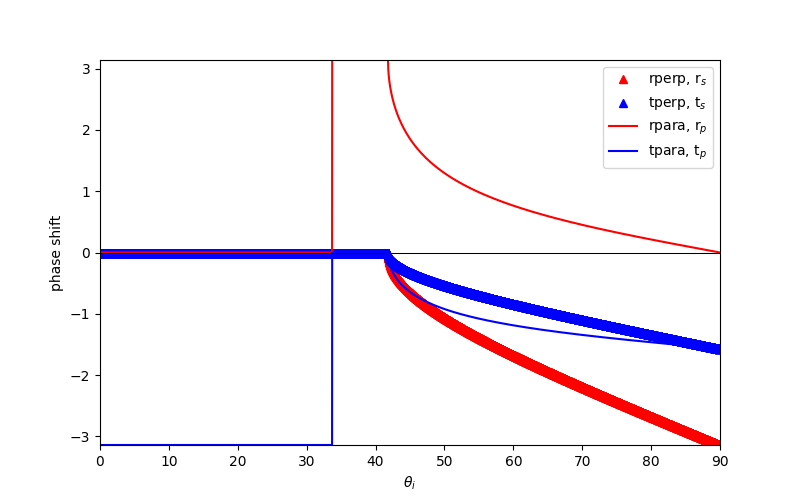

In [5]:
phasePlot(rperp, tperp, rpara, tpara)